### Physics-Informed Target Engineering Investigation

### Objective
This notebook investigates how target formulation influences predictive maintenance modeling performance.

Earlier modeling experiments revealed that time-derived pseudo-RUL targets caused the model to rely heavily on lifecycle progression variables rather than physical degradation behavior.

To address this, a physics-informed target engineering approach was explored using degradation-based failure proximity derived from differential pressure measurements.

The notebook focuses on:

- constructing a physics-informed degradation target
- investigating target leakage
- redesigning feature sets to reduce leakage
- evaluating whether degradation dynamics alone contain meaningful predictive information

#### Load Dependencies

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import warnings
warnings.filterwarnings('ignore')

#### Load Datasets

In [21]:
train = pd.read_csv('../Data/train_engineered_v2.csv')
test = pd.read_csv('../Data/test_engineered_v2.csv')

In [22]:
print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

Train Shape: (39420, 20)
Test Shape: (39414, 20)


#### Encode Categorical Variables

In [23]:
combined = pd.concat([train, test], axis=0)

combined = pd.get_dummies(
    combined,
    columns=["Dust", "Dust_feed_group", "Flow_group"],
    drop_first=True,
    dtype=int
)


train_encoded = combined.iloc[:len(train)]
test_encoded = combined.iloc[len(train):]

#### Physics-Informed Target Rngineering

###### Instead of defining Remaining Useful Life (RUL) purely from elapsed operational time, a degradation-based target was explored. The target was defined as: Target Capacity = 600 − Differential Pressure, where 600 Pa represents the filter failure threshold described in the dataset documentation. This formulation aligns the target more closely with physical degradation behavior rather than purely temporal lifecycle progression.

In [24]:
# Creating new target
train_encoded["target_capacity"] = (
    600 - train_encoded["Differential_pressure"]
)

test_encoded["target_capacity"] = (
    600 - test_encoded["Differential_pressure"]
)

#### Initial Physics-Informed Modeling

In [25]:
X_train = train_encoded.drop(
    columns=[
        "RUL",
        "target_capacity",
        "Data_No",
        "max_time",
        "Differential_pressure"
    ],
    errors="ignore"
)

y_train = train_encoded["target_capacity"]



X_test = test_encoded.drop(
    columns=[
        "RUL",
        "target_capacity",
        "Data_No",
        "max_time",
        "Differential_pressure"
    ],
    errors="ignore"
)

y_test = test_encoded["target_capacity"]

In [26]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    min_samples_split=5,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [27]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    root_mean_squared_error
)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))

MAE: 0.018076439475179788
MSE: 0.003560556548210956
R2 Score: 0.9999997546337505
RMSE: 0.05967039926304295


###### An initial Random Forest model was trained using the physics-informed target formulation. Only the raw Differential Pressure variable was removed to avoid direct target leakage. The objective of this experiment was to evaluate whether pressure-derived degradation features would become more predictive under a physically aligned target formulation.

#### Initial Feature Importance Analysis

In [28]:
importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
)

importance.sort_values(ascending=False).head(15)

pressure_ratio                           8.812022e-01
remaining_pressure_capacity              1.187974e-01
pressure_rate                            5.711830e-08
pressure_growth_rate                     5.498756e-08
rolling_pressure_mean                    5.412959e-08
rolling_pressure_std                     5.412624e-08
rate_ratio_interaction                   5.294198e-08
normalized_time                          3.679812e-08
Time                                     2.643812e-08
Flow_rate                                2.382910e-08
pressure_acceleration                    2.305325e-08
cumulative_pressure                      2.106691e-08
Dust_feed                                6.492473e-09
Flow_group_Medium                        5.956228e-09
Dust_ISO 12103-1, A3 Medium Test Dust    3.164393e-09
dtype: float64

#### Plot Importance

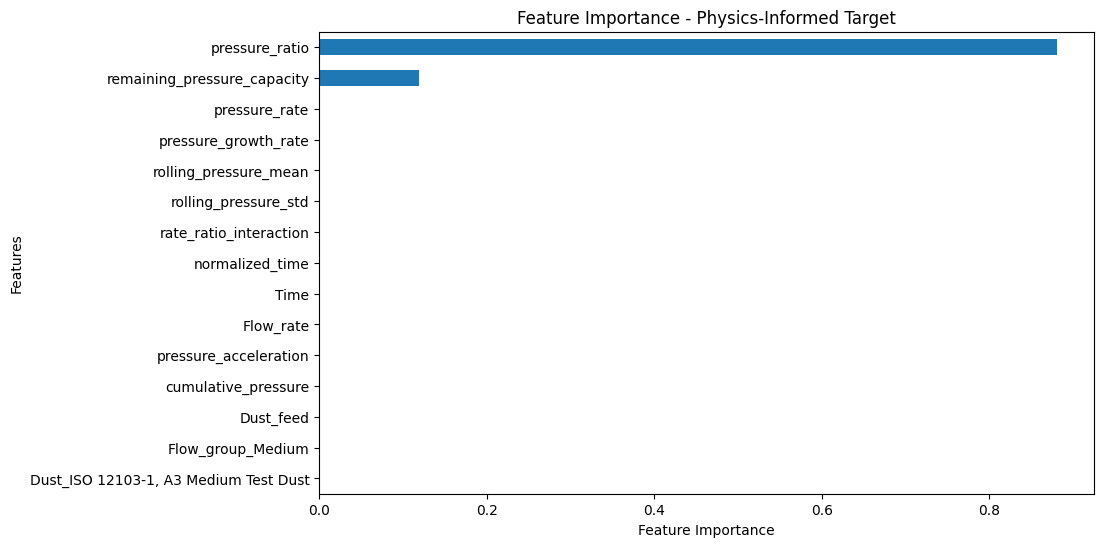

In [29]:
importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10,6))

importance.head(15).plot(kind='barh')

plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Feature Importance - Physics-Informed Target")

plt.gca().invert_yaxis()

plt.show()

###### Feature importance analysis was performed to understand which variables dominated prediction behavior under the physics-informed target formulation.

#### Leakage Investigation

###### The initial experiment produced near-perfect predictive performance.However, feature importance analysis revealed that several engineered variables encoded information extremely close to the target itself. In particular: **pressure_ratio**, **remaining_pressure_capacity**, **rolling pressure  statistics** were heavily derived from Differential Pressure, which also defined the target formulation. This introduced substantial target leakage, causing the model to indirectly reconstruct the target rather than learn generalized degradation behavior.

#### Leakage-Aware Feature Redesign

In [30]:
drop_cols_v2 = [
    "RUL",
    "target_capacity",
    "Data_No",
    "max_time",

    # Direct leakage variables
    "Differential_pressure",
    "pressure_ratio",
    "remaining_pressure_capacity",

    # Indirect pressure magnitude leakage
    "rolling_pressure_mean",
    "rolling_pressure_std",
    "cumulative_pressure"
]

X_train_v2 = train_encoded.drop(
    columns=drop_cols_v2,
    errors="ignore"
)

y_train_v2 = train_encoded["target_capacity"]


X_test_v2 = test_encoded.drop(
    columns=drop_cols_v2,
    errors="ignore"
)

y_test_v2 = test_encoded["target_capacity"]

###### To reduce target leakage, variables directly representing pressure magnitude or smoothed pressure magnitude were removed from the feature space. The revised experiment focused on evaluating whether degradation dynamics alone contained meaningful predictive information. 

###### Removed variables included:

###### - Differential Pressure
###### - pressure_ratio
###### - remaining_pressure_capacity
###### - rolling pressure statistics
###### - cumulative pressure magnitude

#### Refined Modeling Experiment

In [31]:
model_v2 = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    min_samples_split=5,
    random_state=42
)

model_v2.fit(X_train_v2, y_train_v2)

y_pred_v2 = model_v2.predict(X_test_v2)

###### A second Random Forest model was trained using the refined leakage-aware feature set. This experiment evaluates whether degradation progression dynamics remain predictive even after removing direct target-proxy variables.

In [32]:
print("MAE:", mean_absolute_error(y_test_v2, y_pred_v2))
print("MSE:", mean_squared_error(y_test_v2, y_pred_v2))
print("R2 Score:", r2_score(y_test_v2, y_pred_v2))
print("RMSE:", root_mean_squared_error(y_test_v2, y_pred_v2))

MAE: 11.740856872545828
MSE: 901.7219971352429
R2 Score: 0.9378602357197175
RMSE: 30.02868623725059


#### Refined Feature Importance Analysis

In [33]:
importance_v2 = pd.Series(
    model_v2.feature_importances_,
    index=X_train_v2.columns
)

importance_v2.sort_values(ascending=False).head(15)

pressure_growth_rate                     0.586050
Time                                     0.297958
normalized_time                          0.108793
Flow_rate                                0.005874
Dust_ISO 12103-1, A3 Medium Test Dust    0.000722
Dust_feed                                0.000413
Dust_ISO 12103-1, A4 Coarse Test Dust    0.000054
Dust_feed_group_Low                      0.000047
Dust_feed_group_Medium                   0.000042
Flow_group_Medium                        0.000014
rate_ratio_interaction                   0.000011
pressure_rate                            0.000010
pressure_acceleration                    0.000007
Flow_group_Low                           0.000004
dtype: float64

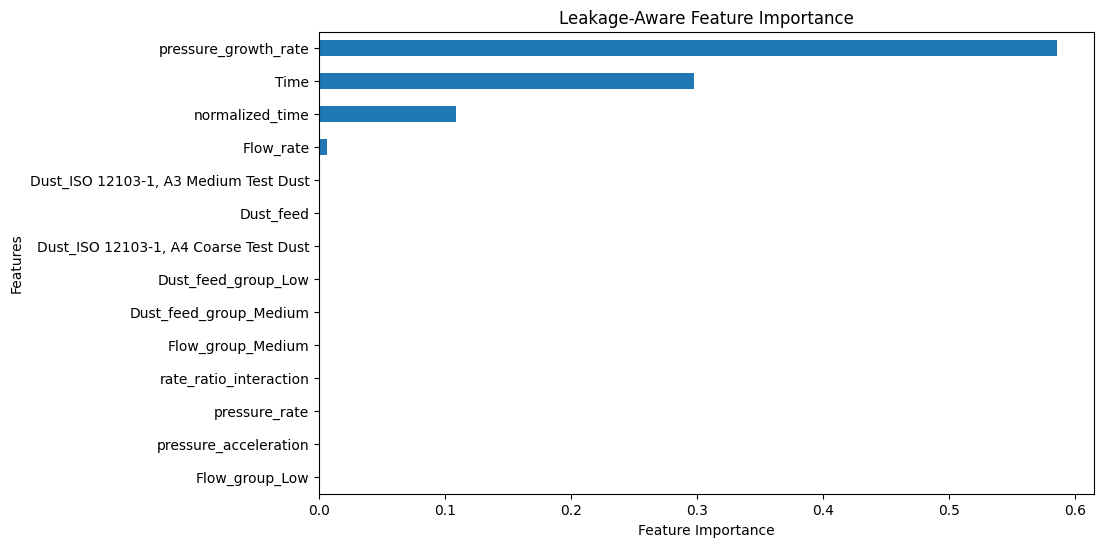

In [34]:
importance_v2 = importance_v2.sort_values(ascending=False)

plt.figure(figsize=(10,6))

importance_v2.head(15).plot(kind='barh')

plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Leakage-Aware Feature Importance")

plt.gca().invert_yaxis()

plt.show()

#### Final Interpretation and Conclusions

#### 
The refined leakage-aware experiment demonstrated that degradation-dynamic variables retained strong predictive power even after direct pressure-magnitude leakage variables were removed.

Feature importance analysis revealed that:

- pressure_growth_rate
- lifecycle progression (time)
- normalized operational progression

became the dominant predictive signals.

These findings suggest that physically meaningful degradation dynamics contain substantial predictive information about failure proximity independently of direct pressure magnitude reconstruction.

Most importantly, this investigation demonstrated how strongly predictive maintenance performance depends on:

- target engineering
- feature-target alignment
- leakage-aware feature design

The notebook highlights the importance of carefully distinguishing between physically meaningful predictive signals and variables that indirectly encode the target itself.

#### Save Model

In [35]:
import joblib

# Save final leakage-aware model
joblib.dump(
    model_v2,
    '../models/physics_informed_rf_model.pkl'
)

# Save feature columns
joblib.dump(
    X_train_v2.columns.tolist(),
    '../models/physics_informed_features.pkl'
)

print("Model and feature schema saved successfully.")

Model and feature schema saved successfully.
